# Generovanie grafov pre bakalársku prácu – PaySim fraud detection

Tento notebook obsahuje **kód na vygenerovanie grafov použitých v kapitole metodiky experimentov**.  
SHAP grafy sú zámerne vynechané.

Generované grafy:

1. Nerovnováha tried v datasete PaySim  
2. AUPRC a ROC-AUC pri plnom feature sete  
3. Precision / Recall / F1 pri plnom feature sete  
4. Porovnanie SMOTENC vs. class_weight pri 3-feature baseline  
5. Recall vs. počet false positives  
6. Porovnanie full-feature modelov s hybridom AE→LGBM  

Notebook je samostatný: výsledkové tabuľky sú vložené priamo v kóde, takže grafy sa dajú obnoviť aj bez opätovného tréningu modelov.


In [1]:
# Základné knižnice
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Výstupný priečinok pre grafy
OUT_DIR = "figures_generated"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 250

print("Grafy sa budú ukladať do:", os.path.abspath(OUT_DIR))


Grafy sa budú ukladať do: /Users/antonhurny/Downloads/figures_generated


## 1. Vstupné tabuľky výsledkov

V tejto časti sú zadané výsledky experimentov, ktoré sa používajú na generovanie grafov.

Ak neskôr znovu natrénuješ modely, stačí prepísať hodnoty v týchto tabuľkách a spustiť notebook znova.


In [2]:
# Výsledky plného feature setu
full_results = pd.DataFrame([
    {"model": "RandomForest", "AUPRC": 1.000000, "ROC_AUC": 1.000000, "Precision": 1.0000, "Recall": 1.0000, "F1": 1.0000, "threshold": 0.10},
    {"model": "LightGBM",     "AUPRC": 0.999996, "ROC_AUC": 1.000000, "Precision": 1.0000, "Recall": 0.9992, "F1": 0.9996, "threshold": 0.01},
    {"model": "XGBoost",      "AUPRC": 0.999953, "ROC_AUC": 0.999999, "Precision": 0.9968, "Recall": 0.9976, "F1": 0.9972, "threshold": 0.73},
    {"model": "DecisionTree", "AUPRC": 0.996839, "ROC_AUC": 0.998796, "Precision": 0.9992, "Recall": 0.9976, "F1": 0.9984, "threshold": 0.01},
])

full_results


,model,AUPRC,ROC_AUC,Precision,Recall,F1,threshold
0,RandomForest,1.000000,1.000000,1.0000,1.0000,1.0000,0.10
1,LightGBM,0.999996,1.000000,1.0000,0.9992,0.9996,0.01
2,XGBoost,0.999953,0.999999,0.9968,0.9976,0.9972,0.73
3,DecisionTree,0.996839,0.998796,0.9992,0.9976,0.9984,0.01


In [3]:
# Výsledky 3-feature baseline experimentu: step / type / amount
baseline_3f = pd.DataFrame([
    {"model": "XGBoost", "method": "SMOTENC(0.05)", "AUPRC": 0.34130259396749707, "ROC_AUC": 0.9113345144696412, "Precision": 0.7099767981438515, "Recall": 0.24440894568690097, "F1": 0.36363636363636365, "TP": 306, "FP": 125, "FN": 946, "TN": 88089},
    {"model": "XGBoost", "method": "class_weight",   "AUPRC": 0.3324354785973295,  "ROC_AUC": 0.9147213326204768, "Precision": 0.978448275862069,  "Recall": 0.18130990415335463, "F1": 0.3059299191374663,  "TP": 227, "FP": 5,   "FN": 1025, "TN": 88209},
    {"model": "LogReg",  "method": "SMOTENC(0.05)", "AUPRC": 0.20111247161701587, "ROC_AUC": 0.8078585180345994, "Precision": 0.34893048128342247, "Recall": 0.2084664536741214,  "F1": 0.261,              "TP": 261, "FP": 487, "FN": 991,  "TN": 87727},
    {"model": "LogReg",  "method": "class_weight",   "AUPRC": 0.18471864632318905, "ROC_AUC": 0.8973521839969327, "Precision": 0.31748071979434445, "Recall": 0.19728434504792333, "F1": 0.24334975369458128, "TP": 247, "FP": 531, "FN": 1005, "TN": 87683},
])

baseline_3f["label"] = baseline_3f["model"] + " | " + baseline_3f["method"]
baseline_3f


,model,method,AUPRC,ROC_AUC,Precision,Recall,F1,TP,FP,FN,TN,label
0,XGBoost,SMOTENC(0.05),0.341303,0.911335,0.709977,0.244409,0.363636,306,125,946,88089,XGBoost | SMOTENC(0.05)
1,XGBoost,class_weight,0.332435,0.914721,0.978448,0.181310,0.305930,227,5,1025,88209,XGBoost | class_weight
2,LogReg,SMOTENC(0.05),0.201112,0.807859,0.348930,0.208466,0.261000,261,487,991,87727,LogReg | SMOTENC(0.05)
3,LogReg,class_weight,0.184719,0.897352,0.317481,0.197284,0.243350,247,531,1005,87683,LogReg | class_weight


In [4]:
# Hybridný model Autoencoder -> LightGBM
ae_lgbm = pd.DataFrame([
    {"model": "AE→LGBM", "AUPRC": 0.687350, "ROC_AUC": 0.925273, "latent_dim": 16, "N_AE": 300000}
])

ae_lgbm


,model,AUPRC,ROC_AUC,latent_dim,N_AE
0,AE→LGBM,0.68735,0.925273,16,300000


## 2. Nerovnováha tried v PaySim

Graf ukazuje extrémnu nerovnováhu tried. Použitá je logaritmická os, pretože podvodné transakcie tvoria len malý zlomok všetkých záznamov.


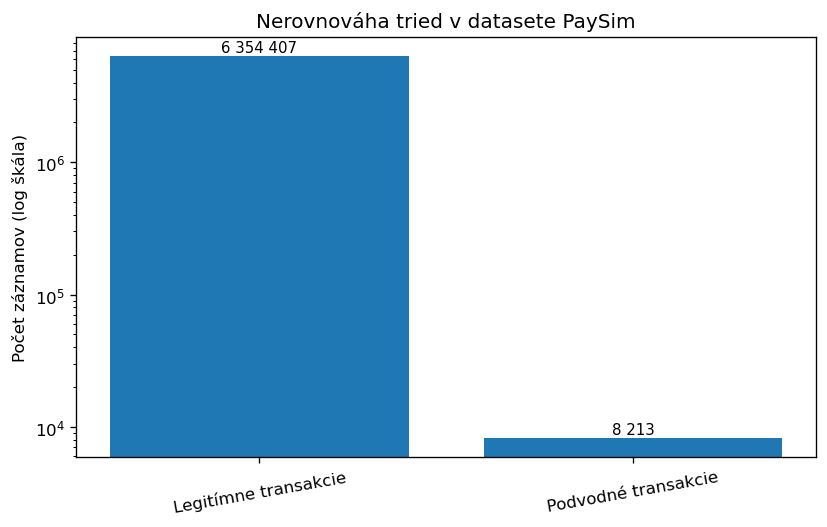

Uložené: figures_generated/fig_4_2_class_imbalance.png


In [5]:
# Nerovnováha tried
# Ak máš načítaný raw dataset, môžeš hodnoty nahradiť skutočným value_counts().
imbalance = pd.DataFrame([
    {"class": "Legitímne transakcie", "count": 6_354_407},
    {"class": "Podvodné transakcie", "count": 8_213},
])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(imbalance["class"], imbalance["count"])
ax.set_yscale("log")
ax.set_ylabel("Počet záznamov (log škála)")
ax.set_title("Nerovnováha tried v datasete PaySim")
for i, v in enumerate(imbalance["count"]):
    ax.text(i, v*1.08, f"{v:,}".replace(",", " "), ha="center", fontsize=9)
plt.xticks(rotation=10)
plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_2_class_imbalance.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 3. AUPRC a ROC-AUC pri plnom feature sete

Graf porovnáva separačnú schopnosť modelov pri použití plného feature setu vrátane zostatkových a odvodených príznakov.


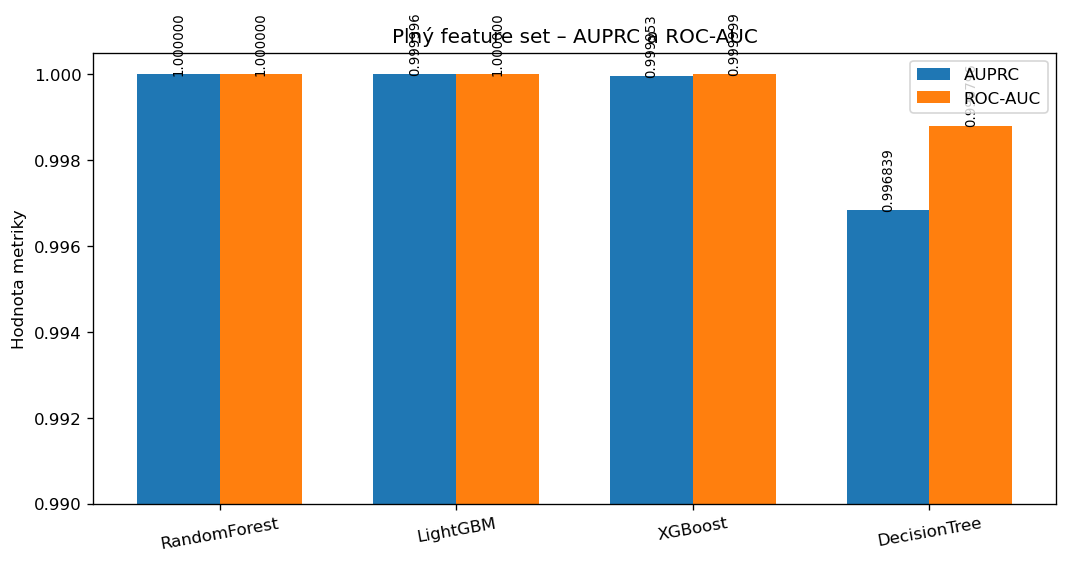

Uložené: figures_generated/fig_4_3_full_model_auprc_roc_auc.png


In [6]:
# AUPRC a ROC-AUC pri plnom feature sete
x = np.arange(len(full_results))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width/2, full_results["AUPRC"], width, label="AUPRC")
ax.bar(x + width/2, full_results["ROC_AUC"], width, label="ROC-AUC")
ax.set_xticks(x)
ax.set_xticklabels(full_results["model"], rotation=10)
ax.set_ylim(0.99, 1.0005)
ax.set_ylabel("Hodnota metriky")
ax.set_title("Plný feature set – AUPRC a ROC-AUC")
ax.legend()

for i, row in full_results.iterrows():
    ax.text(i - width/2, row["AUPRC"] + 0.00005, f"{row['AUPRC']:.6f}", ha="center", fontsize=8, rotation=90)
    ax.text(i + width/2, row["ROC_AUC"] + 0.00005, f"{row['ROC_AUC']:.6f}", ha="center", fontsize=8, rotation=90)

plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_3_full_model_auprc_roc_auc.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 4. Precision, Recall a F1 pri plnom feature sete

Tento graf zobrazuje výkonnosť modelov po aplikovaní prahu vybraného na validačnej množine.


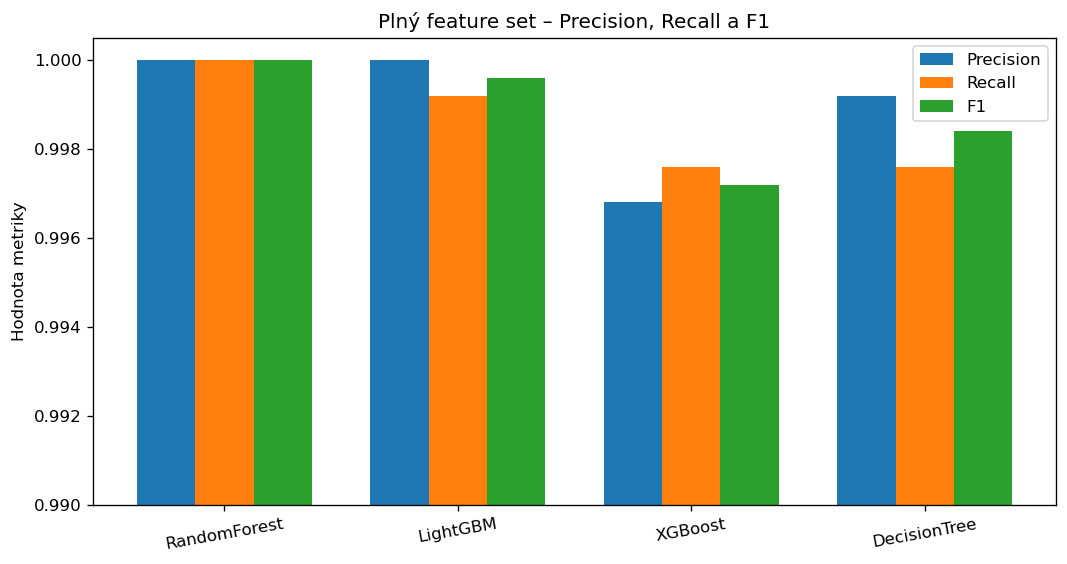

Uložené: figures_generated/fig_4_4_full_model_precision_recall_f1.png


In [7]:
# Precision, Recall, F1 pri plnom feature sete
x = np.arange(len(full_results))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width, full_results["Precision"], width, label="Precision")
ax.bar(x,         full_results["Recall"],    width, label="Recall")
ax.bar(x + width, full_results["F1"],        width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(full_results["model"], rotation=10)
ax.set_ylim(0.99, 1.0005)
ax.set_ylabel("Hodnota metriky")
ax.set_title("Plný feature set – Precision, Recall a F1")
ax.legend()

plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_4_full_model_precision_recall_f1.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 5. SMOTENC vs. class_weight pri 3-feature baseline

Porovnanie režimov riešenia nerovnováhy tried pri zjednodušenom baseline modeli s príznakmi `step`, `type` a `amount`.


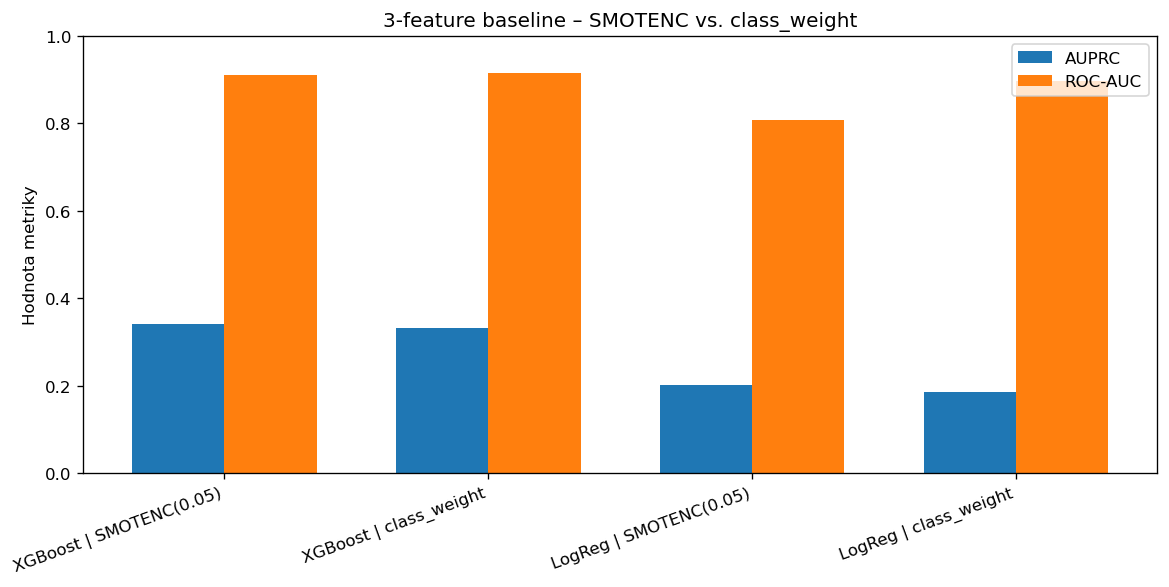

Uložené: figures_generated/fig_4_5_3feature_smote_classweight.png


In [8]:
# AUPRC a ROC-AUC pre SMOTENC vs class_weight
x = np.arange(len(baseline_3f))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, baseline_3f["AUPRC"], width, label="AUPRC")
ax.bar(x + width/2, baseline_3f["ROC_AUC"], width, label="ROC-AUC")
ax.set_xticks(x)
ax.set_xticklabels(baseline_3f["label"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Hodnota metriky")
ax.set_title("3-feature baseline – SMOTENC vs. class_weight")
ax.legend()
plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_5_3feature_smote_classweight.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 6. Recall vs. počet false positives

Graf ukazuje praktický trade-off: SMOTENC zvyšuje recall, ale zároveň môže výrazne zvýšiť počet falošne pozitívnych detekcií.


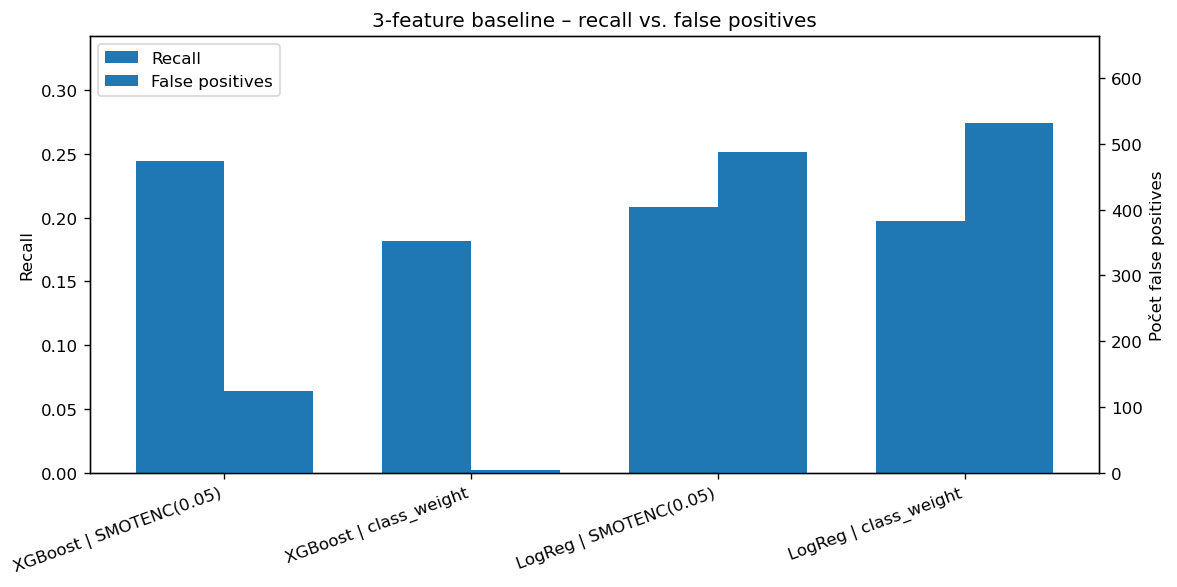

Uložené: figures_generated/fig_4_6_recall_false_positives.png


In [9]:
# Recall vs false positives
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(baseline_3f))
bar1 = ax1.bar(x - 0.18, baseline_3f["Recall"], width=0.36, label="Recall")
ax1.set_ylabel("Recall")
ax1.set_ylim(0, max(baseline_3f["Recall"]) * 1.4)
ax1.set_xticks(x)
ax1.set_xticklabels(baseline_3f["label"], rotation=20, ha="right")

ax2 = ax1.twinx()
bar2 = ax2.bar(x + 0.18, baseline_3f["FP"], width=0.36, label="False positives")
ax2.set_ylabel("Počet false positives")
ax2.set_ylim(0, max(baseline_3f["FP"]) * 1.25)

ax1.set_title("3-feature baseline – recall vs. false positives")

# spoločná legenda
handles = [bar1, bar2]
labels = ["Recall", "False positives"]
ax1.legend(handles, labels, loc="upper left")

plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_6_recall_false_positives.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 7. Porovnanie full-feature modelov s hybridom AE→LGBM

Graf ukazuje, že hybridný model Autoencoder → LightGBM dosahuje slušný výkon, ale na PaySim neprekonáva modely trénované priamo na plnom feature sete.


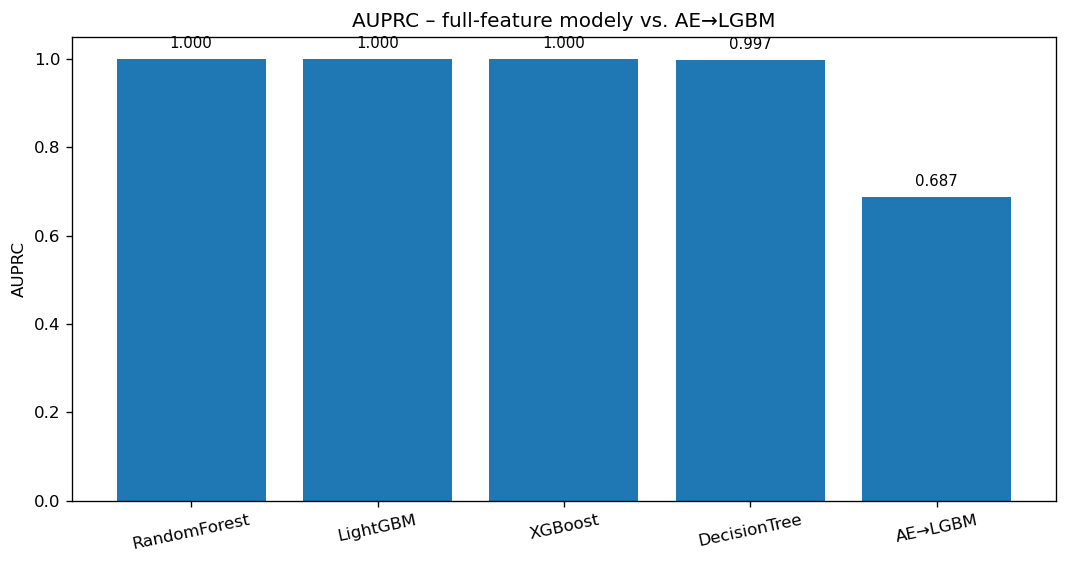

Uložené: figures_generated/fig_4_7_full_vs_ae_lgbm_auprc.png


In [10]:
# AUPRC porovnanie full modelov a AE->LGBM
compare_ae = pd.concat([
    full_results[["model", "AUPRC"]].assign(group="Full features"),
    ae_lgbm[["model", "AUPRC"]].assign(group="AE→LGBM")
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(compare_ae["model"], compare_ae["AUPRC"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUPRC")
ax.set_title("AUPRC – full-feature modely vs. AE→LGBM")
plt.xticks(rotation=12)
for i, v in enumerate(compare_ae["AUPRC"]):
    ax.text(i, v + 0.025, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
path = os.path.join(OUT_DIR, "fig_4_7_full_vs_ae_lgbm_auprc.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Uložené:", path)


## 8. Export zoznamu vygenerovaných grafov

Táto bunka vypíše všetky uložené PNG súbory. V Colabe ich nájdeš v priečinku `figures_generated`.


In [11]:
import glob
generated = sorted(glob.glob(os.path.join(OUT_DIR, "*.png")))
for path in generated:
    print(path)


figures_generated/fig_4_2_class_imbalance.png
figures_generated/fig_4_3_full_model_auprc_roc_auc.png
figures_generated/fig_4_4_full_model_precision_recall_f1.png
figures_generated/fig_4_5_3feature_smote_classweight.png
figures_generated/fig_4_6_recall_false_positives.png
figures_generated/fig_4_7_full_vs_ae_lgbm_auprc.png


## 9. Voliteľné: ZIP export grafov

Ak chceš všetky grafy stiahnuť naraz, spusti túto bunku. Vytvorí súbor `figures_generated.zip`.


In [12]:
import zipfile, glob

zip_path = "figures_generated.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for path in sorted(glob.glob(os.path.join(OUT_DIR, "*.png"))):
        z.write(path, arcname=os.path.basename(path))

print("ZIP vytvorený:", os.path.abspath(zip_path))


ZIP vytvorený: /Users/antonhurny/Downloads/figures_generated.zip
